# Preprocessing

Companion notebook for the RDDAC [documentation](https://rddac.readthedocs.io). It is written to stand on its own: every step is annotated so the notebook reads top to bottom.

## Walkthrough

1. run the reference preprocessing on the small bundle with the `rddac preprocess` CLI,
2. inspect the self-describing processed files (shapes, parameters, cleaning statistics),
3. draw the processing figures per modality with the package's own plot functions, the same figures as in the documentation,
4. adjust parameters reproducibly via `--dump-config` / `--config`,
5. preview the pointcloud stage (validity mask now, the full raw-vs-processed comparison once the simulations are present),
6. stream the processed layer with `rddac.streaming.iter_view`: same views, same manifest, `data_dir=` switched.

## Assumptions

- This notebook lives in `notebooks/` of the repository and reads the dataset from `../data/` (on your machine: the directory `rddac download` wrote to).
- The data directory contains `metadata.json`, `process_parameters.csv`, and at least the bundled `sample.zip`.
- `pip install 'rddac[preprocessing]'` was run (scipy + scikit-learn; only the pointcloud stage needs them).
- Processed files are written to `../data/processed/`; the raw files are never modified.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import h5py
import matplotlib.pyplot as plt

import rddac
from rddac._preprocess import visualize
from rddac._preprocess.h5_access import open_raw
print('rddac', rddac.__version__)

from pathlib import Path
DATA_DIR = Path('../data')
# DATA_DIR = Path('./data')   # uncomment instead when running from the repository root
assert (DATA_DIR / 'metadata.json').is_file(), f'{DATA_DIR} does not contain the dataset'
PROCESSED_DIR = DATA_DIR / 'processed'

rddac 1.0.1


## 1. Run the reference preprocessing

The CLI is the supported entry point. It reads each raw experiment (zips or loose `.h5`), runs the selected modalities, and writes a NEW `<id>.h5` into `PROCESSED_DIR`; raw files are opened read-only and never modified. Re-runs append: groups that already exist are skipped unless `--overwrite` is passed.

Only the experiments present locally are processed, so the small bundle (18 experiments, one per category) finishes in a few seconds. `-q` suppresses the progress bar and implies `--yes`.

In [2]:
!rddac preprocess oil force sheet --data-dir {DATA_DIR} -q
processed_ids = sorted(int(p.stem) for p in PROCESSED_DIR.glob('*.h5'))
print(f'{len(processed_ids)} processed files: {processed_ids[:6]} ...')

18 processed files: [0, 500, 1002, 1500, 2000, 2500] ...


## 2. Inspect the self-describing output

Each processed group carries three kinds of attributes: the column layout and units (`columns`, `units`), the **parameter values actually used** (e.g. `hampel_k`), and the **per-file cleaning statistics** (e.g. `n_hampel_outliers`). A processed file therefore documents itself even when it is separated from the code that made it.

In [3]:
experiment_id = processed_ids[0]
with h5py.File(PROCESSED_DIR / f'{experiment_id:04d}.h5') as f:
    print('force', f['force/data'].shape, '| oil', f['oil_thickness/data'].shape, '| sheet', f['sheet_thickness/data'].shape)
    print({k: f['oil_thickness'].attrs[k] for k in ('hampel_window', 'hampel_k', 'n_nan_removed', 'n_hampel_outliers')})

force (600, 8) | oil (200, 2) | sheet (200, 2)
{'hampel_window': np.int64(5), 'hampel_k': np.float64(3.0), 'n_nan_removed': np.int64(0), 'n_hampel_outliers': np.int64(2)}


## 3. Processing figures per modality

The figures on the [preprocessing pages](https://rddac.readthedocs.io/en/latest/preprocessing/) of the documentation are drawn by `rddac._preprocess.visualize`. Each `plot_*_processing` function takes the **raw** arrays and derives the processed view by calling the modality's own `process` function, so what you see is by construction what `rddac preprocess` does: the same functions, on the same bundle, produce the documentation images.

The raw arrays of every experiment are read once; the plotting cells below are then independent of each other.

In [4]:
raw_oil, raw_force, raw_sheet = {}, [], []
for exp_id in processed_ids:
    with open_raw(exp_id, DATA_DIR) as raw:
        raw_oil[exp_id] = raw['oil_thickness/data'][:]
        raw_force.append(raw['force/data'][:])
        raw_sheet.append(raw['sheet_thickness/data'][:])
print(f'raw arrays of {len(processed_ids)} experiments loaded')

raw arrays of 18 experiments loaded


**Oil film**: one experiment. (a) the raw readings with the 200 mm truncation line, (b) after truncation and dropout removal, with the Hampel-flagged outliers as red crosses, (c) the fixed 0–199 mm grid written to the processed file.

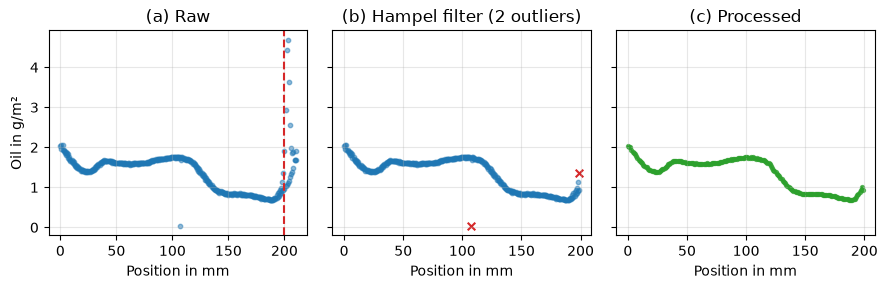

In [5]:
visualize.plot_oil_processing(raw_oil[experiment_id])
plt.show()

**Press force**: all experiments of the bundle overlaid. (a) the raw total force with the forming window (grey = discarded), (b) the processed curves: windowed, time re-zeroed, rest offset removed.

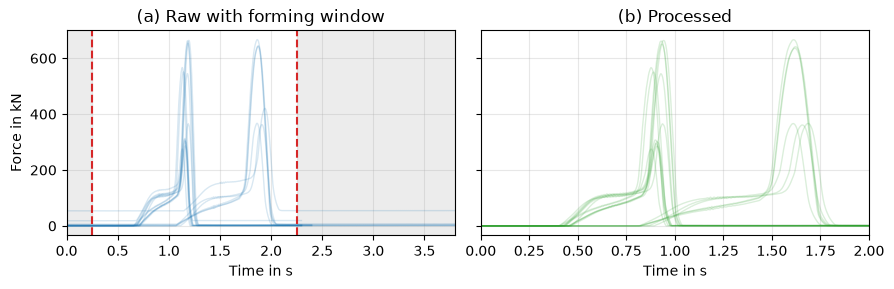

In [6]:
visualize.plot_force_processing(raw_force)
plt.show()

**Sheet thickness**: all experiments overlaid. (a) the raw traverses with the tail-selection cutoff (grey = the unstable head that is discarded), (b) the processed profiles, positions normalised to start at 0. Negative sensor-error codes are hidden here; in the processed file they are `NaN`.

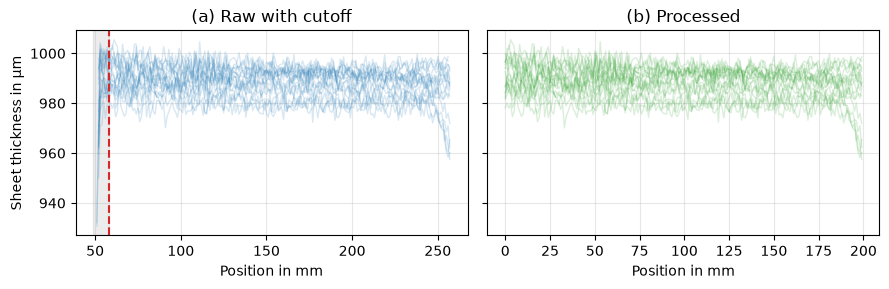

In [7]:
visualize.plot_sheet_processing(raw_sheet)
plt.show()

## 4. Adjust parameters reproducibly

`--dump-config` prints the complete defaults as an editable TOML; `--config my.toml` applies your variant, and the values used are stamped into the processed files. Publishing the TOML next to your code makes a variant exactly reproducible: raw dataset DOI + `rddac` version + TOML.

In [8]:
!rddac preprocess --dump-config | head -12

# rddac preprocess configuration: these are the defaults (the
# reference recipe). Edit values and pass the file via
#   rddac preprocess --config my.toml
# Publish it next to your code to make the variant reproducible.

[oil]
max_sensor_position = 200
output_length = 200
hampel_window = 5
hampel_k = 3.0
value_quantization = 0.01



## 5. The pointcloud stage

With the full release and the DDACS simulations present (`rddac download`, without `--no-sim`), `rddac preprocess pointcloud` cleans and aligns the scans; on first use it retrains the random-forest fin classifier from the labels bundled with the package (one-time, ~30–90 min). Without the simulations the stage is skipped with a notice (or fails with an actionable error when named explicitly); nothing is written.

Its first step, the **validity mask** from the luminescence grid, needs only raw data, so it can be previewed on the small bundle: (a) the raw grid, (b) the connected foreground patches, (c) the mask after the patch-size filter, (d) the packed `uint8` image written to the processed file.

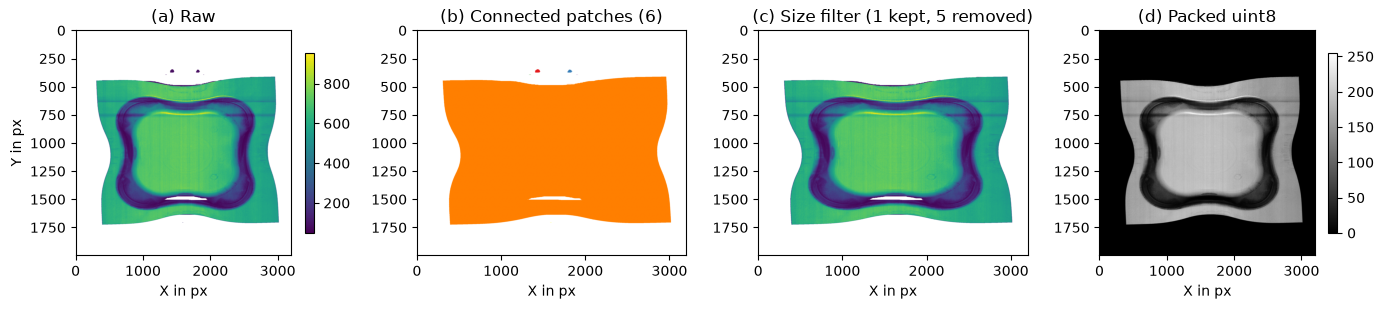

In [9]:
with open_raw(experiment_id, DATA_DIR) as raw:
    grp = raw['pointcloud/op10']
    shape = (int(grp.attrs['y_shape']), int(grp.attrs['x_shape']))
    z_2d = grp['z'][:].reshape(shape)
    lumi_2d = grp['luminescence'][:].reshape(shape)

visualize.plot_luminescence_processing(lumi_2d)
plt.show()

The full comparison (the raw calibrated scan next to the cleaned, ICP-aligned point cloud) is drawn as soon as a processed pointcloud group exists for this experiment.

In [10]:
with h5py.File(PROCESSED_DIR / f'{experiment_id:04d}.h5') as f:
    if 'pointcloud' in f:
        grp = f['pointcloud/op10']
        visualize.plot_pointcloud_processing(z_2d, lumi_2d, grp['z'][:], stats=dict(grp.attrs))
        plt.show()
    else:
        print('no processed pointcloud for this experiment yet - run: rddac preprocess pointcloud --workers 8 (needs the simulations)')

no processed pointcloud for this experiment yet - run: rddac preprocess pointcloud --workers 8 (needs the simulations)


## 6. Stream the processed layer

The processed files keep the raw HDF5 paths (`force/data`, `oil_thickness/data`, ...), so the Croissant manifest downloaded with the dataset (`DATA_DIR / 'metadata.json'`) describes both layers and every published view works on the processed directory. Switching is `data_dir=`; `source=` points at the local manifest so nothing is fetched.

In [11]:
from rddac.streaming import iter_view

MANIFEST = DATA_DIR / 'metadata.json'
for layer, directory in (('raw', DATA_DIR), ('processed', PROCESSED_DIR)):
    for rec in iter_view('force-curve', data_dir=directory, source=MANIFEST, sim_ids=[experiment_id]):
        print(f"{layer:9s} experiment {rec['_sim_id']:04d}: force_data{rec['force_data'].shape}")

raw       experiment 0000: force_data(1140, 8)


processed experiment 0000: force_data(600, 8)


## Where to go next

- Everything from notebook 06 (custom views via `rddac.add_view`, `export_to_numpy`, `RDDACDataset`) applies to the processed layer unchanged: pass `data_dir=PROCESSED_DIR` and `source=MANIFEST`.
- [Preprocessing documentation](https://rddac.readthedocs.io/en/latest/preprocessing/): schema, parameters, output-directory rules, and how to replace a stage with your own algorithm.
- [Point Clouds](https://rddac.readthedocs.io/en/latest/preprocessing/pointcloud/): the full pipeline and the held-out quality numbers of the fin classifier.
